# V5 — Retrieval Evaluation

*2026-05*

Compares V1 (TF-IDF), V2 (Embeddings bge-small), and V3 (ChromaDB) using standard IR metrics.

**Metrics:** Precision@K, Recall@K, NDCG@K, MRR, Hit Rate@K  
**Test set:** 16 queries for 8 topics. Each topic has a keyword query and a natural language query with the same ground truth, to expose how each version handles different query styles.

In [7]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv('../.env')
HF_TOKEN = os.environ.get('HF_TOKEN', '')

from src.recommender import (
    load_books_dataset,
    build_tfidf,
    build_embeddings, recommend_embeddings,
    build_chroma, recommend_chroma,
)
from src.evaluator import load_eval_queries, run_evaluation, summarise, summarise_by_type

## Setup:

In [8]:
df = load_books_dataset()
print(f'Dataset: {df.shape[0]:,} books')

Dataset: 16,559 books


In [19]:
# V1
tfidf = build_tfidf(df)
print('V1 TF-IDF ready!')

# V2 with bge-small model
embedder, emb_vectors = build_embeddings(df, model_name='BAAI/bge-small-en-v1.5')
print('V2 Embeddings ready!')

# V3
store = build_chroma(df, hf_token=HF_TOKEN)
print('V3 ChromaDB ready!')

V1 TF-IDF ready!


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading book vectors from cache: data/book_vectors_BAAI_bge-small-en-v1.5.npy
V2 Embeddings ready!
V3 ChromaDB ready!


## Test set

In [10]:
queries = load_eval_queries('../evaluation/eval_queries.json')
print(f'{len(queries)} queries loaded')

pd.DataFrame([{
    'id': q['id'],
    'type': q['type'],
    'query': q['query'],
    'relevant_books': len(q['relevant_titles']),
} for q in queries])

16 queries loaded


,id,type,query,relevant_books
0,q01,keyword,dystopia totalitarian government surveillance ...,5
1,q02,natural_language,a society where an authoritarian government mo...,5
2,q03,keyword,magic school young wizard powers coming of age,3
3,q04,natural_language,a young person who discovers they have magical...,3
4,q05,keyword,regency romance England social class marriage ...,4
5,q06,natural_language,a romantic story set in 19th century England d...,4
6,q07,keyword,horror psychological haunted isolation madness,3
7,q08,natural_language,a terrifying story where a character becomes i...,3
8,q09,keyword,fantasy adventure quest fellowship journey,5
9,q10,natural_language,an epic fantasy adventure where a group of unl...,5


## Evaluation

In [11]:
TOP_N = 5

rec_v1 = lambda q, n: tfidf.recommend(q, n, df)
rec_v2 = lambda q, n: recommend_embeddings(q, n, df, embedder, emb_vectors)
rec_v3 = lambda q, n: recommend_chroma(q, n, store)

In [12]:
results_v1 = run_evaluation(queries, rec_v1, top_n=TOP_N, version_name='V1 TF-IDF')
results_v2 = run_evaluation(queries, rec_v2, top_n=TOP_N, version_name='V2 Embeddings')
results_v3 = run_evaluation(queries, rec_v3, top_n=TOP_N, version_name='V3 ChromaDB')

all_results = pd.concat([results_v1, results_v2, results_v3], ignore_index=True)
print(f'{len(queries)} queries × 3 versions = {len(all_results)} rows')

16 queries × 3 versions = 48 rows


## Results

In [20]:
print('Mean across all 16 queries')
display(summarise(all_results))

Mean across all 16 queries


,precision@5,recall@5,ndcg@5,mrr,hit_rate@5
version,,,,,
V1 TF-IDF,0.025,0.021,0.021,0.042,0.125
V2 Embeddings,0.012,0.012,0.011,0.021,0.062
V3 ChromaDB,0.025,0.042,0.023,0.025,0.125


In [21]:
print('by query type')
display(summarise_by_type(all_results))

by query type


precision@5  recall@5  ndcg@5    mrr  \
version       type                                                     
V1 TF-IDF     keyword                 0.025     0.021   0.021  0.042   
              natural_language        0.025     0.021   0.021  0.042   
V2 Embeddings keyword                 0.025     0.025   0.021  0.042   
              natural_language        0.000     0.000   0.000  0.000   
V3 ChromaDB   keyword                 0.025     0.042   0.023  0.025   
              natural_language        0.025     0.042   0.023  0.025   

                                hit_rate@5  
version       type                          
V1 TF-IDF     keyword                0.125  
              natural_language       0.125  
V2 Embeddings keyword                0.125  
              natural_language       0.000  
V3 ChromaDB   keyword                0.125  
              natural_language       0.125

## Visualisations

/var/folders/6f/sv4nlj5d60zcwmb6819y184m0000gn/T/ipykernel_5789/2205553715.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(versions, rotation=15, ha='right', fontsize=9)
/var/folders/6f/sv4nlj5d60zcwmb6819y184m0000gn/T/ipykernel_5789/2205553715.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(versions, rotation=15, ha='right', fontsize=9)
/var/folders/6f/sv4nlj5d60zcwmb6819y184m0000gn/T/ipykernel_5789/2205553715.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(versions, rotation=15, ha='right', fontsize=9)
/var/folders/6f/sv4nlj5d60zcwmb6819y184m0000gn/T/ipykernel_5789/2205553715.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e.

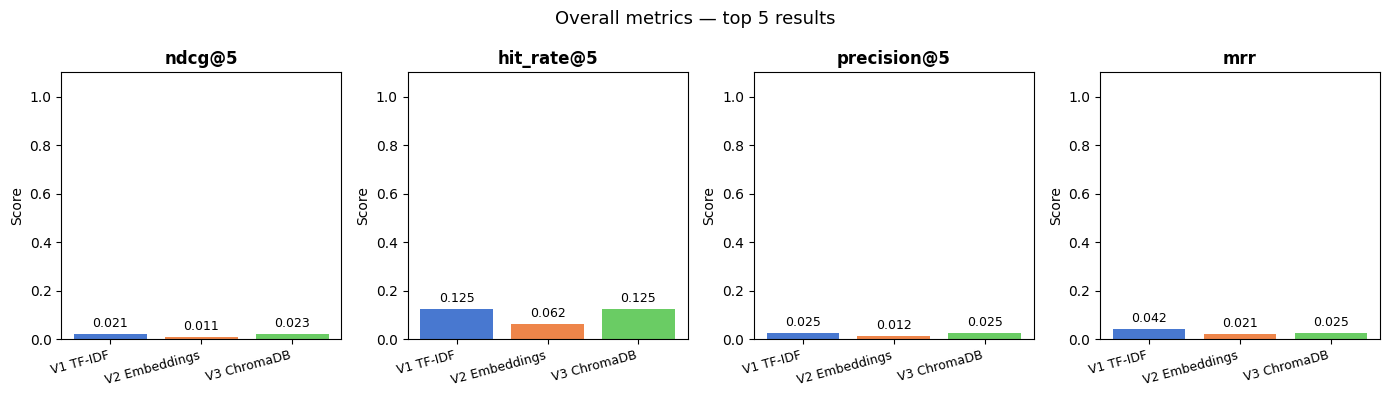

In [ ]:
# Bar chart: NDCG@5 and Hit Rate@5 per version
summary = summarise(all_results).reset_index()
metrics = [f'ndcg@{TOP_N}', f'hit_rate@{TOP_N}', f'precision@{TOP_N}', 'mrr']
versions = summary['version'].tolist()
colors = sns.color_palette('muted', len(versions))

fig, axes = plt.subplots(1, len(metrics), figsize=(14, 4))
for ax, metric in zip(axes, metrics):
    bars = ax.bar(versions, summary[metric], color=colors)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(versions, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Score')

plt.suptitle(f'Overall metrics — top {TOP_N} results', fontsize=13)
plt.tight_layout()
plt.show()

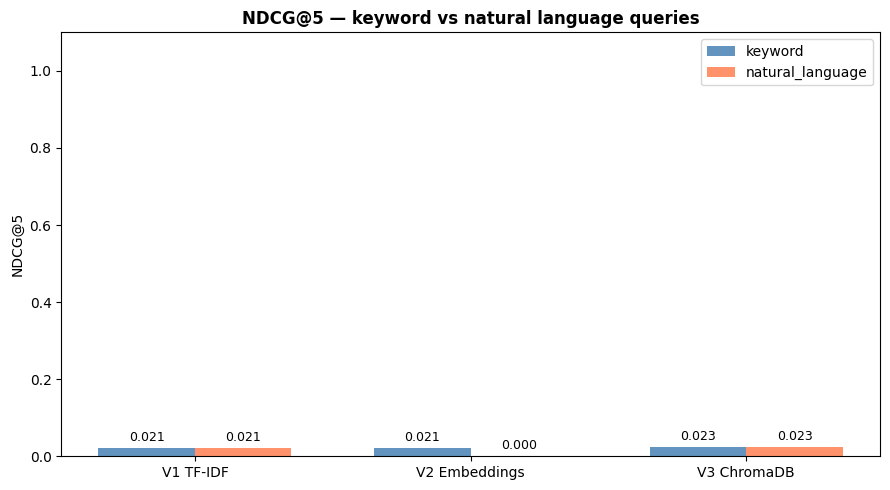

In [16]:
# NDCG@5 split by query type: keyword vs natural_language
# V1 degrades on natural language, V3 stays consistent
ndcg_col = f'ndcg@{TOP_N}'
type_summary = summarise_by_type(all_results).reset_index()

query_types = type_summary['type'].unique()
x = np.arange(len(versions))
width = 0.35
type_colors = ['steelblue', 'coral']

fig, ax = plt.subplots(figsize=(9, 5))
for i, (qtype, color) in enumerate(zip(query_types, type_colors)):
    scores = [
        type_summary.loc[
            (type_summary['version'] == v) & (type_summary['type'] == qtype), ndcg_col
        ].values[0] if len(type_summary.loc[
            (type_summary['version'] == v) & (type_summary['type'] == qtype)
        ]) > 0 else 0
        for v in versions
    ]
    bars = ax.bar(x + (i - 0.5) * width, scores, width, label=qtype, color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(versions, fontsize=10)
ax.set_ylabel(f'NDCG@{TOP_N}')
ax.set_ylim(0, 1.1)
ax.set_title(f'NDCG@{TOP_N} — keyword vs natural language queries', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

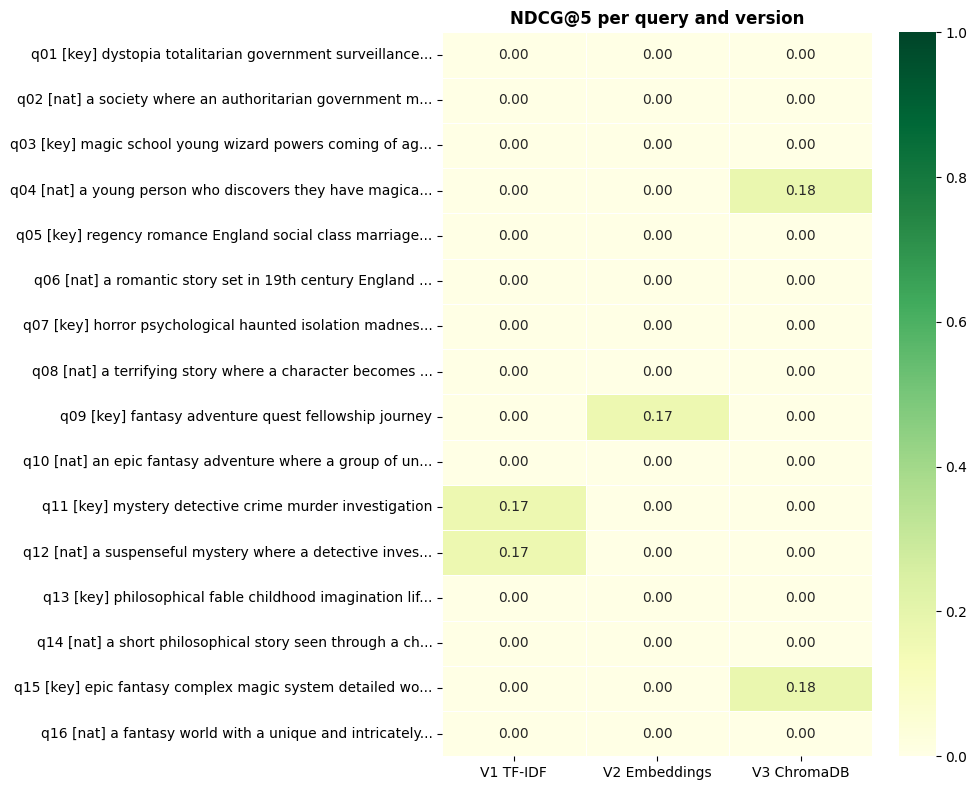

In [ ]:
# Heatmap: NDCG@5 per query × version
ndcg_col = f'ndcg@{TOP_N}'
pivot = all_results.pivot(index='query_id', columns='version', values=ndcg_col)

# add query text and type as index labels
query_labels = {
    q['id']: f"{q['id']} [{q['type'][:3]}] {q['query'][:45]}..."
    if len(q['query']) > 45 else f"{q['id']} [{q['type'][:3]}] {q['query']}"
    for q in queries
}
pivot.index = [query_labels[i] for i in pivot.index]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='YlGn',
    vmin=0, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title(f'NDCG@{TOP_N} per query and version', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Qualitative analysis

For a specific query, show what each version actually returned (useful to understand *why* a version scores low).

In [ ]:
FOCUS_QUERY_ID = 'q02'

q = next(x for x in queries if x['id'] == FOCUS_QUERY_ID)
relevant = set(q['relevant_titles'])

print(f"Query: '{q['query']}'")
print(f"Type: {q['type']}")
print(f"Ground truth: {q['relevant_titles']}\n")

for name, fn in [('V1 TF-IDF', rec_v1), ('V2 Embeddings', rec_v2), ('V3 ChromaDB', rec_v3)]:
    res = fn(q['query'], TOP_N)
    print(f'── {name} ──')
    if res.empty:
        print('  No results')
    else:
        for i, row in res.iterrows():
            hit = '✓' if row['title'] in relevant else ' '
            print(f"  {hit} {row['title']} (score: {row.get('score', '—')})")
    print()

Query: 'a society where an authoritarian government monitors and controls its citizens'
Type: natural_language
Ground truth: ['Nineteen Eighty-Four', 'Animal Farm', 'Brave New World', 'The Iron Heel', 'Kazohinia']

── V1 TF-IDF ──
    Hawksbill Station (score: 0.119)
    Westwind (score: 0.11)
    Ossian's Ride (score: 0.098)
    The Mass Psychology of Fascism (score: 0.094)
    Veracity (score: 0.085)

── V2 Embeddings ──
    The Transparent Society (score: 0.685)
    Facial Justice (score: 0.682)
    The Enigma of Japanese Power (score: 0.68)
    The Star Fraction (score: 0.674)
    Linda and Morris Tannehill (score: 0.673)

── V3 ChromaDB ──
    The Transparent Society (score: 0.685)
    The Enigma of Japanese Power (score: 0.68)
    The Star Fraction (score: 0.674)
    Hegemony or Survival (score: 0.66)
    States and Social Revolutions (score: 0.656)

